In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline  
# 嵌入单元格

In [5]:
def f(x):
    return 3*x**2 - 4*x + 5

In [6]:
f(3.0)


20.0

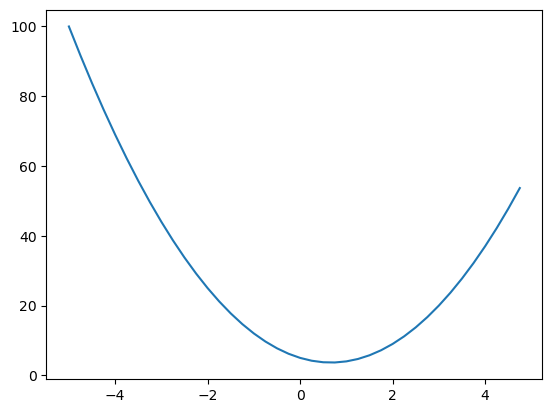

In [7]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [8]:
h = 0.000001
x = 2/3
(f(x+h) - f(x)) / h

2.999378523327323e-06

In [9]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

4.0


In [ ]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
a += h
d2 = a * b + c

print("d1", d1)
print("d2", d2)
print("slope", (d2-d1) / h)

# switch to b, c

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [ ]:
import math

class Value:
    def __init__(self,data,_children=(),_op="",label=""):
        self.data = data
        self._prev = set(_children) # for efficiency
        self._op = _op
        self._backward = lambda:None # define the _backward function in the method
        self.label = label
        self.grad = 0.0  # maintains the derivative of L with respect to this value (L: network loss function), 0 means no effect to loss function 

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward(): 
            ''' _backward of __add__'''
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad 
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += out.grad * other * (self.data**(other-1))
        out._backward = _backward
        return out
    
    def __rmul__(self,other): # other * self
        return self * other

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        def _backward():
            self.grad += out.grad * out.data
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        # a / b = a * (1 / b) = a * (b ^ (-1))
        # so we choose to implement the oparation of X to the K
        return self * other**-1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(t,(self,), "tanh")
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    
    
a = Value(2.0,label="a")
b = Value(-3.0,label="b")
c = Value(10.0,label="c")

e = a*b;e.label="e"

d = e+c; d.label="d" # add __add__ and __mul__
# (a.__mul__(b)).__add__(c) 

# add connetive tissue: _children

# add what operation created this value: _op

f = Value(-2.0, label="f")
L = d * f;L.label="L"
L

Value(data=-8.0)

In [16]:
a = Value(2.0)
b = Value(4.0)

2 + a

Value(data=4.0)

In [2]:
from graphviz import Digraph
# need python API

def trace(root):
    nodes, edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot =Digraph(format='svg', graph_attr={'rankdir':'LR'}) # LR = left to right

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid+n._op , label=n._op)
            # and connect this node to it
            dot.edge(uid+n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

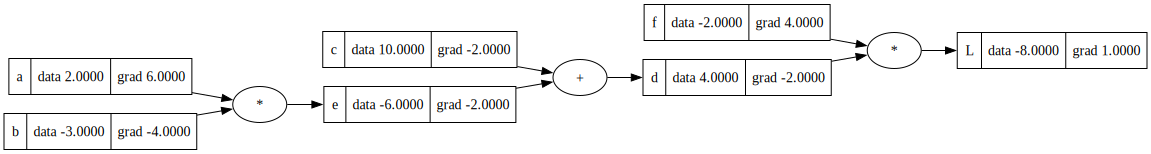

In [47]:
draw_dot(L)

# this is  visualizing the forward pass

In [46]:
# the crux of backpropagation -> the chain rule in Calculus

# dd / dc = 1.0
# dd / de = 1.0
# d = c + e

# WANT: 
# dL / dc

# KNOW:
# dL / dd
# dd / dc 

# SOLVE:
# dL / dc = (dL / dd) * (dd / dc)

# like this:
L.grad = 1.0
# L = f * d
f.grad = 4.0 # d
d.grad = -2.0 # f
# d = c + e
c.grad = -2.0 * 1.0
e.grad = -2.0 * 1.0
# e = a * b
a.grad = -2.0 * 1.0 * -3.0 # b
b.grad = -2.0 * 1.0 * 2.0 # a 

In [48]:
# nudge inputs to try to make L go up
a.data += 0.01 * a.grad # go in the direction of the gradient
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


In [49]:
def lol():

    h = 0.0001

    a = Value(2.0,label="a")
    b = Value(-3.0,label="b")
    c = Value(10.0,label="c")
    e = a*b;e.label="e"
    d = e+c; d.label="d"
    f = Value(-2.0, label="f")
    L = d * f;L.label="L"
    L1 = L.data

    a = Value(2.0 + h,label="a")
    b = Value(-3.0,label="b")
    c = Value(10.0,label="c")
    e = a*b;e.label="e"
    d = e+c; d.label="d"
    f = Value(-2.0, label="f")
    L = d * f;L.label="L"
    L2 = L.data

    print((L2 - L1) / h) # the derivative of L with respect to a

lol()

6.000000000021544


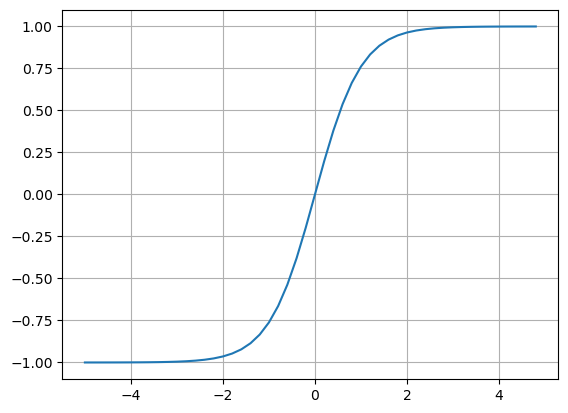

In [ ]:
# please see the cs231n convolutional neural networks for visual recognition

# activation 
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

In [3]:
import math

# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")
# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# bias of the neuron
b = Value(6.8813735870195432, label="b")
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = "x1*w1"
x2w2 = x2 * w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1+x2*w2"
n = x1w1x2w2 + b; n.label = "n"

# tanh: hyperbolic functions-> need implement exponentiation, back to Value
o = n.tanh()


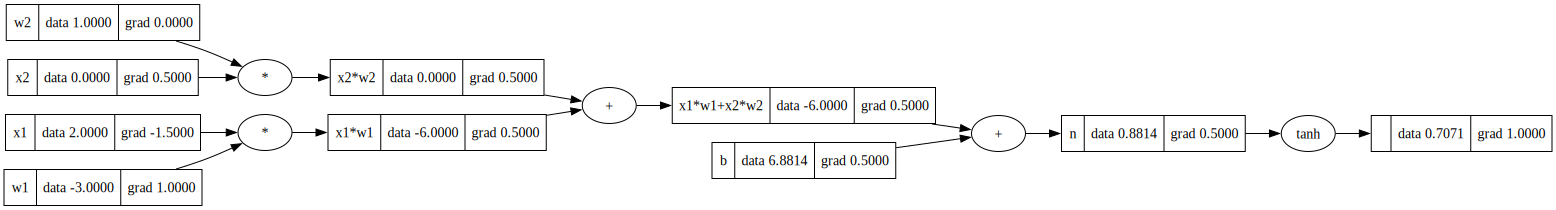

In [8]:
draw_dot(o)

In [7]:
o.backward()

In [ ]:
o.grad = 1.0

# o = tanh(n)
# do / dn = 1 - tanh(n)**2 = 1 - o ** 2
# n.grad = 1 - o.data ** 2 
n.grad = 0.5

x1w1x2w2.grad = 0.5
b.grad = 0.5

x1w1.grad = 0.5
x2w2.grad = 0.5

x1.grad = x1w1.grad * w1.data
w1.grad = x1w1.grad * x1.data

x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data

In [6]:
# implement the backward pass automatically -> Value._backward
o.grad = 1.0

o._backward()

n._backward()

# even b._backward() is correct, because lambda:None
b._backward()

x1w1x2w2._backward()

x1w1._backward()

x2w2._backward()



In [ ]:
# the ordering of graphs can be achieved using topological sort
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
print(topo) # Post-order DFS traversal

for node in reversed(topo):
    node._backward()

# to hide this functionality in the Value Class

[Value(data=6.881373587019543), Value(data=-3.0), Value(data=2.0), Value(data=-6.0), Value(data=0.0), Value(data=1.0), Value(data=0.0), Value(data=-6.0), Value(data=0.8813735870195432), Value(data=0.7071067811865476)]


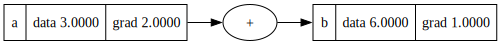

In [12]:
# still have a big bug
a = Value(3.0, label="a")
b = a + a; b.label = "b"
b.backward()
draw_dot(b) # a.grad is not correct!


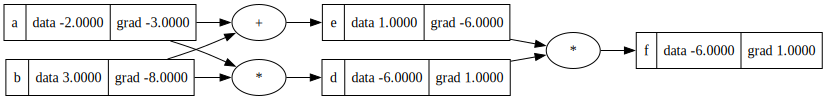

In [13]:
a = Value(-2.0, label="a")
b = Value(3.0, label = 'b')
d = a * b; d.label = "d"
e = a + b; e.label = "e"
f = d * e; f.label = "f"

f.backward()
draw_dot(f)

# the caused reason of the bug is that a variable is used more than once
# the solution is that we have to accumulate gradients

In [ ]:
# create more expressions, like a + 1, oirginal Value definition cant realize this expression cause 1 do not have the attribute 'data'

# see the Value concrete function like 'other = other if isinstance(other,Value) else Value(other)'

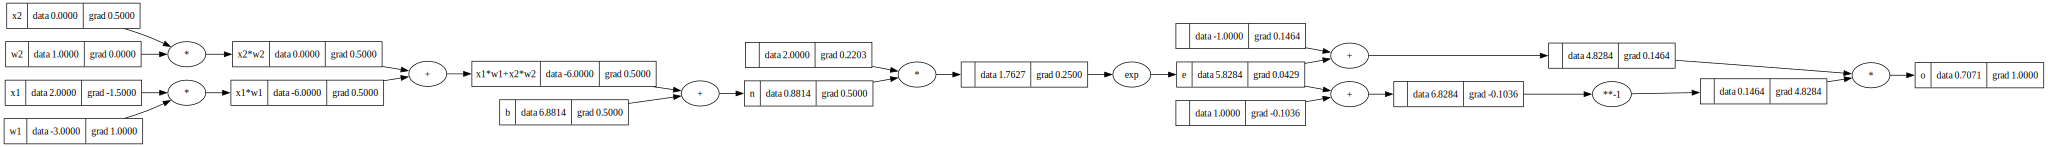

In [6]:
# after implement like __sub__ __neg__ __truediv__ ... operation, redefine the o 

# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")
# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# bias of the neuron
b = Value(6.8813735870195432, label="b")
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = "x1*w1"
x2w2 = x2 * w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1+x2*w2"
n = x1w1x2w2 + b; n.label = "n"

# tanh: hyperbolic functions-> need implement exponentiation, back to Value
e = (2*n).exp(); e.label = "e"
o = (e - 1) / (e + 1)
o.label = "o"
o.backward()
draw_dot(o)


In [30]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params
    
class MLP:
    def __init__(self, nin, nouts):
        sz  = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data=-0.7419121187882848)

In [31]:
len(n.parameters())

41

In [75]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0]
ypred = [n(x) for x in xs]
ypred

[Value(data=0.9899950878575432),
 Value(data=-0.9999999196345094),
 Value(data=-0.9999998888412747),
 Value(data=0.9901202082863212)]

In [72]:
loss = sum((yout - ygt)**2 for ygt,yout in zip(ys, ypred))
loss

Value(data=0.003984680042463947)

In [73]:
loss.backward()

In [20]:
n.layers[0].neurons[0].w[0].grad

2.8991891558064857

In [74]:
for p in n.parameters():
    p.data -= 0.1 * p.grad

In [33]:
loss

Value(data=6.036044862843154)

In [78]:
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt,yout in zip(ys,ypred))

    # backward pass 
    for p in n.parameters():
        p.grad = 0
    loss.backward()

    # update
    for p in n.parameters():
        p.data -= 0.1 * p.grad

    print(k, loss.data)

0 0.00016736243328014264
1 0.00016712983981735432
2 0.0001668978916041219
3 0.00016666658595782468
4 0.0001664359202107058
5 0.0001662058917097494
6 0.00016597649781660253
7 0.000165747735907461
8 0.00016551960337295605
9 0.00016529209761808542
10 0.00016506521606209288
11 0.00016483895613837615
12 0.00016461331529439127
13 0.00016438829099154728
14 0.00016416388070512997
15 0.00016394008192419497
16 0.00016371689215146637
17 0.00016349430890325888
18 0.0001632723297093811
19 0.00016305095211303873
